In [17]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import os

import soundfile as sf

In [58]:
WINDOW_SIZE = 4096
HOP_SIZE = WINDOW_SIZE

NOISY_AUDIO_PATH = 'LibriSpeechNoisy\\'

## Pre-processing

In [59]:
def get_flac_file_paths(root_folder):
    flac_file_paths = []
    for dirpath, _, filenames in os.walk(root_folder):
        for file in filenames:
            if file.endswith('.flac'):
                full_path = os.path.join(dirpath, file)
                flac_file_paths.append(full_path)
    return flac_file_paths


def calc_audio_stft(audio_data):
    spectogram = np.abs(librosa.stft(audio_data, n_fft=WINDOW_SIZE, hop_length=HOP_SIZE))  # Magnitude of the STFT
    spectogram = librosa.amplitude_to_db(spectogram, ref=np.max)
    return spectogram


def plot_waveform(audio_data, sample_rate):
    sample_count = len(audio_data)
    recording_time = sample_count / sample_rate

    time_axis = np.linspace(0, recording_time, sample_count)

    # Plot the waveform
    plt.figure(figsize=(10, 4))
    plt.plot(time_axis, audio_data, color="green")
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')
    #plt.xlim([start_time, end_time])
    plt.title('Amplitude Graph of the WAV File')
    plt.show()


def apply_noising_on_audio(file_path, audio_data, sample_rate, noise_factor = 0.01):
    noise = np.random.randn(len(audio_data))
    noisy_data = audio_data + noise_factor * noise  # Adjust noise factor

    file_name = os.path.basename(file_path).removesuffix(".flac")
    folders = file_path.replace('LibriSpeech/', '').rsplit('\\', 1)[0]
    new_file_name = file_name + "-noisy.flac"

    new_path = NOISY_AUDIO_PATH + folders
    print(new_path)

    if not os.path.exists(new_path):
        os.makedirs(new_path)
    
    sf.write(new_path + "\\" + file_name + "-noisy.flac", noisy_data, sample_rate)

    return noisy_data


def plot_spectogram(spectogram, sample_rate):
    # Plot the spectrogram
    plt.figure(figsize=(10, 6))
    librosa.display.specshow(spectogram, sr=sample_rate, x_axis='time', y_axis='log', n_fft=WINDOW_SIZE, hop_length=HOP_SIZE)
    plt.colorbar(format='%+2.0f dB')
    plt.yticks([64,100,1000,4096, 8000])
    #plt.ylim(0, sample_rate / 2)  # Ensures Y-axis goes up to 8000 Hz
    plt.title('Spectrogram')
    plt.show()

In [60]:
data_paths = get_flac_file_paths("LibriSpeech/")

In [61]:
raw_data, sample_rate = librosa.load(data_paths[0], sr=None)

In [62]:
raw_data_noisy = apply_noising_on_audio(data_paths[0], raw_data, sample_rate)

LibriSpeechNoisy\103\1240


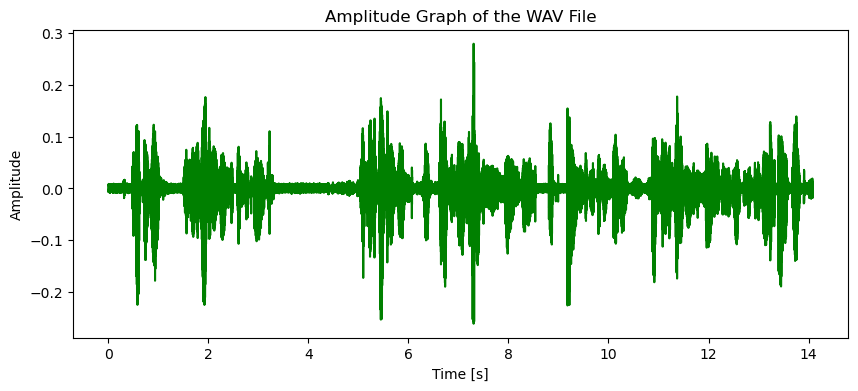

In [63]:
plot_waveform(raw_data, sample_rate)

In [64]:
spectogram = calc_audio_stft(raw_data)

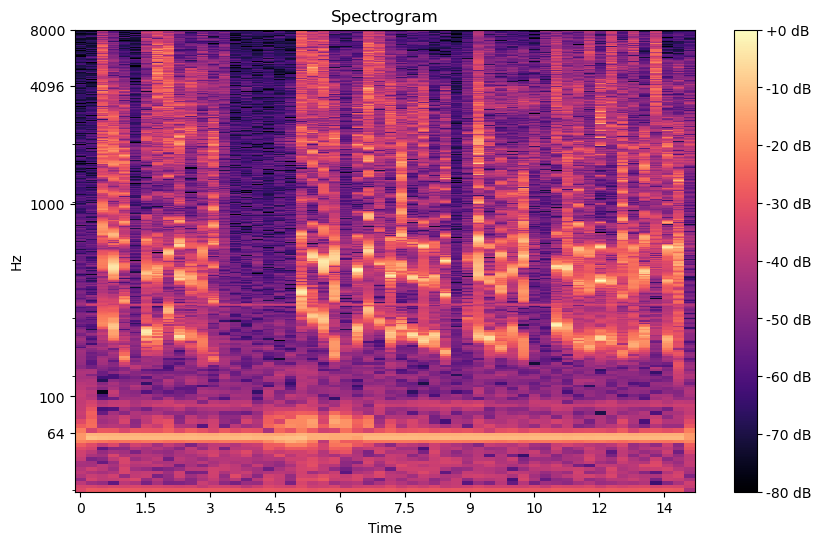

In [65]:
plot_spectogram(spectogram, sample_rate)

In [66]:
spectogram_noisy = calc_audio_stft(raw_data_noisy)

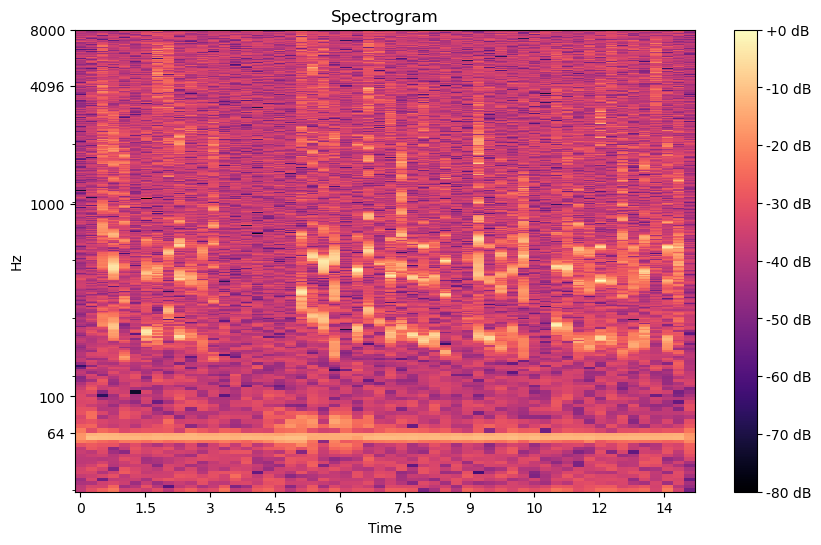

In [67]:
plot_spectogram(spectogram_noisy, sample_rate)

In [68]:
#minmax-normalization
clean_spectogram = (spectogram - spectogram.min()) / (spectogram.max() - spectogram.min())
noisy_spectogram = (spectogram_noisy - spectogram_noisy.min()) / (spectogram_noisy.max() - spectogram_noisy.min())

In [69]:
clean_spectogram = clean_spectogram.reshape((clean_spectogram.shape[0], clean_spectogram.shape[1], 1))  # Add channel dimension
noisy_spectogram = noisy_spectogram.reshape((noisy_spectogram.shape[0], noisy_spectogram.shape[1], 1))

In [70]:
assert(clean_spectogram.shape == noisy_spectogram.shape)

In [71]:
clean_spectogram.shape

(2049, 56, 1)

## Model Creation

In [72]:
from tensorflow.keras import layers, models

In [79]:
def unet_model(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    print(f"Layer 1 shape: {p1.shape}")

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)
    print(f"Layer 2 shape: {p2.shape}")

    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)
    print(f"Layer 3 shape: {p3.shape}")

    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)
    print(f"Layer 4 shape: {p4.shape}")

    # Bottleneck
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)
    print(f"Layer 5 shape: {c5.shape}")

    # Decoder
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    print(f"Layer 6 shape: {u6.shape}")
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    print(f"Layer 7 shape: {u7.shape}")
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    print(f"Layer 8 shape: {u8.shape}")
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    print(f"Layer 9 shape: {u9.shape}")
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = models.Model(inputs=[inputs], outputs=[outputs])

    return model


In [80]:
model = unet_model(input_shape=clean_spectogram.shape)  # Adjust input shape based on your spectrogram size
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])

Layer 1 shape: (None, 1024, 28, 64)
Layer 2 shape: (None, 512, 14, 128)
Layer 3 shape: (None, 256, 7, 256)
Layer 4 shape: (None, 128, 3, 512)
Layer 5 shape: (None, 128, 3, 1024)
Layer 6 shape: (None, 256, 6, 512)


ValueError: A `Concatenate` layer requires inputs with matching shapes except for the concatenation axis. Received: input_shape=[(None, 256, 6, 512), (None, 256, 7, 512)]